In [1]:
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
Datos_evap = pd.read_csv('2023-12-01 evap.csv')
Datos_evap.head()

,x,y,X202312
0,-81.409898,15.66441,-9999.0
1,-80.960740,15.66441,-9999.0
2,-80.511582,15.66441,-9999.0
3,-80.062425,15.66441,-9999.0
4,-79.613267,15.66441,-9999.0


In [3]:
#Remover dados nulos
Datos_evap = Datos_evap[Datos_evap['X202312'] != -9999.0]
Datos_evap.head()

,x,y,X202312
285,-71.977587,12.071149,0.000009
286,-71.528429,12.071149,0.000011
287,-71.079272,12.071149,0.000010
289,-70.180957,12.071149,0.000017
290,-69.731799,12.071149,0.000021


In [4]:
Datos_evap.describe()

,x,y,X202312
count,957.000000,957.000000,9.570000e+02
mean,-73.068331,3.114279,4.088729e-05
std,3.769482,4.589749,1.112245e-05
min,-81.409898,-4.098526,2.433364e-07
25%,-76.020006,-0.954423,3.804297e-05
50%,-72.875902,2.638839,4.375751e-05
75%,-69.731799,7.130415,4.726654e-05
max,-67.036853,12.071149,6.307939e-05


In [5]:
Datos_evap.info()

<class 'pandas.core.frame.DataFrame'>
Index: 957 entries, 285 to 1484
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   x        957 non-null    float64
 1   y        957 non-null    float64
 2   X202312  957 non-null    float64
dtypes: float64(3)
memory usage: 29.9 KB


Text(0.5, 1.0, 'Histograma de Evapotranspiración - Diciembre 2023')

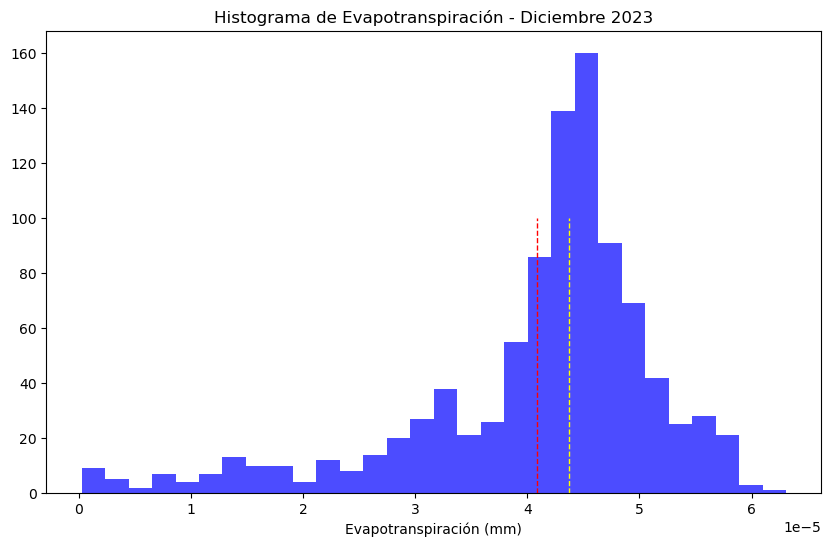

In [6]:
# Histograma de frequencia
plt.figure(figsize=(10, 6))
plt.hist(Datos_evap['X202312'], bins=30, color='blue', alpha=0.7)
plt.vlines(Datos_evap['X202312'].mean(), 0, 100, color='red', linestyle='dashed', linewidth=1)
plt.vlines(Datos_evap['X202312'].median(), 0, 100, color='yellow', linestyle='dashed', linewidth=1)
plt.xlabel('Evapotranspiración (mm)')
plt.title('Histograma de Evapotranspiración - Diciembre 2023')

In [7]:
Datos_evap.rename(columns={'X202312': 'Evapotranspiración'}, inplace=True)
Datos_evap.head()

,x,y,Evapotranspiración
285,-71.977587,12.071149,0.000009
286,-71.528429,12.071149,0.000011
287,-71.079272,12.071149,0.000010
289,-70.180957,12.071149,0.000017
290,-69.731799,12.071149,0.000021


In [8]:
#https://www.researchgate.net/post/How-do-I-convert-ERA-Interim-precipitation-estimates-from-kg-m2-s-to-mm-day

Datos_evap["Evap_mm"] = Datos_evap["Evapotranspiración"] * 30* 24 * 86400  # de Kg/m2/s Convertendo para mm considerando 30 dias e 24 horas
Datos_evap.head()

,x,y,Evapotranspiración,Evap_mm
285,-71.977587,12.071149,0.000009,575.641341
286,-71.528429,12.071149,0.000011,708.306433
287,-71.079272,12.071149,0.000010,601.139788
289,-70.180957,12.071149,0.000017,1071.401891
290,-69.731799,12.071149,0.000021,1278.146734


In [9]:
import geopandas as gpd
import shapely
from shapely.geometry import Polygon, LineString, MultiPolygon, Point


In [10]:
# Crear un GeoDataFrame a partir de Datos_evap
Datos_evap_gdf = gpd.GeoDataFrame(Datos_evap,geometry=gpd.points_from_xy(Datos_evap['x'], Datos_evap['y']), crs="EPSG:4326")
Datos_evap_gdf

,x,y,Evapotranspiración,Evap_mm,geometry
285,-71.977587,12.071149,0.000009,575.641341,POINT (-71.97759 12.07115)
286,-71.528429,12.071149,0.000011,708.306433,POINT (-71.52843 12.07115)
287,-71.079272,12.071149,0.000010,601.139788,POINT (-71.07927 12.07115)
289,-70.180957,12.071149,0.000017,1071.401891,POINT (-70.18096 12.07115)
290,-69.731799,12.071149,0.000021,1278.146734,POINT (-69.7318 12.07115)
...,...,...,...,...,...
1480,-68.833484,-4.098526,0.000050,3136.319364,POINT (-68.83348 -4.09853)
1481,-68.384326,-4.098526,0.000047,2903.527326,POINT (-68.38433 -4.09853)
1482,-67.935168,-4.098526,0.000046,2844.656040,POINT (-67.93517 -4.09853)
1483,-67.486011,-4.098526,0.000045,2825.393773,POINT (-67.48601 -4.09853)


In [11]:
Datos_evap_gdf.explore( column='Evap_mm',
                        cmap='viridis',
                        legend=True,
                        marker_kwds={'radius': 5, 'fillOpacity': 0.7})

In [ ]:
#https://atmamani-github-io.translate.goog/projects/spatial/guide-to-spatial-analysis-2/?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc

In [ ]:
#https://pysal.org/

In [45]:
#https://pysal.org/notebooks/explore/pointpats/centrography.html

In [12]:
from pointpats import PointPattern
from pointpats.centrography import hull, mbr, mean_center, weighted_mean_center, manhattan_median, std_distance,euclidean_median,ellipse

In [13]:
mc = mean_center(Datos_evap_gdf.iloc[:, 0:2].values)
print("Centro medio:", mc)

Centro medio: [-73.06833145   3.11427926]


In [14]:
mcp = weighted_mean_center(Datos_evap_gdf.iloc[:, 0:2].values, 
                           Datos_evap_gdf['Evap_mm'].values)
print("Centro medio ponderado:", mcp)

Centro medio ponderado: [-72.9151902    3.06438803]


In [15]:
import folium

In [16]:
m = Datos_evap_gdf.explore( column='Evap_mm',
                        cmap='viridis',
                        legend=True,
                        marker_kwds={'radius': 5, 'fillOpacity': 0.7},
                        tiles='CartoDB positron')
folium.CircleMarker(
    location=[mcp[1], mcp[0]],  # folium usa [lat, lon] = [y, x]
    radius=10,                   # Tamaño más grande
    color='red',                 # Borde rojo
    fill=True,
    fill_color='red',            # Relleno rojo
    fill_opacity=0.9,            # Casi opaco
    popup=f"Centro medio: {mcp}" # Etiqueta emergente
).add_to(m)
m.fit_bounds([[mcp[1], mcp[0]]], max_zoom=6)
m

In [17]:
def median_center(points, crit=0.0001):
    points = np.asarray(points)
    x0, y0 = points.mean(axis=0)
    dx = np.inf
    dy = np.inf
    iteration = 0
    while np.abs(dx) > crit or np.abs(dy) > crit:
        xd = points[:, 0] - x0
        yd = points[:, 1] - y0
        d = np.sqrt(xd*xd + yd*yd)
        w = 1./d
        w = w / w.sum()
        x1 = w * points[:, 0]
        x1 = x1.sum()
        y1 = w * points[:, 1]
        y1 = y1.sum()
        dx = x1 - x0
        dy = y1 - y0
        iteration +=1 
        print(x0, x1, dx, dy, d.sum(), iteration)
        x0 = x1
        y0 = y1
               
    return x1, y1


In [18]:
median_center(Datos_evap_gdf.iloc[:, 0:2].values, crit=.0001)

-73.06833145264376 -73.01314425412497 0.05518719851879439 -0.021521088620944706 5278.905656719132 1
-73.01314425412497 -72.98748001288405 0.025664241240917818 -0.010034375240567162 5278.295230855731 2
-72.98748001288405 -72.97546671665384 0.01201329623020797 -0.004612244329101678 5278.162081746195 3
-72.97546671665384 -72.96980446791571 0.005662248738133258 -0.0020839845334168494 5278.132847394954 4
-72.96980446791571 -72.96712256361793 0.0026819042977734853 -0.0009262933745972646 5278.126392733984 5
-72.96712256361793 -72.96584789748088 0.0012746661370499623 -0.0004049769707279438 5278.124961672506 6
-72.96584789748088 -72.96524042539723 0.0006074720836579672 -0.00017374802393765876 5278.124643194897 7
-72.96524042539723 -72.96495022546982 0.0002901999274058653 -7.276967078428953e-05 5278.124572035567 8
-72.96495022546982 -72.9648112701653 0.00013895530452145977 -2.947217231508148e-05 5278.124556063645 9
-72.9648112701653 -72.96474457723168 6.669293361483142e-05 -1.1343549402909048e-0

(-72.96474457723168, 3.0744089614091568)

In [19]:
em = euclidean_median(Datos_evap_gdf.iloc[:, 0:2].values)
em

array([-72.96468251,   3.0744044 ])

In [20]:
m = Datos_evap_gdf.explore( column='Evap_mm',
                        cmap='viridis',
                        legend=True,
                        marker_kwds={'radius': 5, 'fillOpacity': 0.7},
                        tiles='CartoDB positron')
folium.CircleMarker(
    location=[mcp[1], mcp[0]],  # folium usa [lat, lon] = [y, x]
    radius=10,                   # Tamaño más grande
    color='red',                 # Borde rojo
    fill=True,
    fill_color='red',            # Relleno rojo
    fill_opacity=0.9,            # Casi opaco
    popup=f"Centro medio: {mcp}" # Etiqueta emergente
).add_to(m)
m.fit_bounds([[mcp[1], mcp[0]]], max_zoom=6)
folium.CircleMarker(
    location=[em[1], em[0]],  # folium usa [lat, lon] = [y, x]
    radius=10,                   # Tamaño más grande
    color='black',                 # Borde rojo
    fill=True,
    fill_color='black',            # Relleno rojo
    fill_opacity=0.9,            # Casi opaco
    popup=f"Centro mediano: {em}" # Etiqueta emergente
).add_to(m)

m

In [21]:
sx, sy, theta = ellipse(Datos_evap_gdf.iloc[:, 0:2].values)
sx, sy, theta

(5.162850491923258, 6.1269924546957535, 0.3276142327276006)

In [22]:
theta_degree = np.degrees(theta) 
theta_degree

18.770912843708242

In [23]:
#Definir componentes de la elipse
ellipse = ((mcp[0], mcp[1]),(sx, sy),theta_degree)

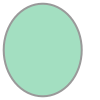

In [24]:
ell  = shapely.affinity.scale(Point(ellipse[0]).buffer(1), ellipse[1][0], ellipse[1][1]) #tomamos sigmax y sigmay para crear elipse
ell

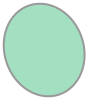

In [29]:
ellr = shapely.affinity.rotate(ell,ellipse[2]) #rotamos la elipse
ellr

In [30]:
ellr = gpd.GeoSeries([ellr])
ellr

0    POLYGON ((-68.02694 4.72572, -67.85723 4.14911...
dtype: geometry

In [31]:
m = Datos_evap_gdf.explore( column='Evap_mm',
                        cmap='viridis',
                        legend=True,
                        marker_kwds={'radius': 5, 'fillOpacity': 0.7},
                        tiles='CartoDB positron')
folium.CircleMarker(
    location=[mcp[1], mcp[0]],  # folium usa [lat, lon] = [y, x]
    radius=10,                   # Tamaño más grande
    color='red',                 # Borde rojo
    fill=True,
    fill_color='red',            # Relleno rojo
    fill_opacity=0.9,            # Casi opaco
    popup=f"Centro medio: {mcp}" # Etiqueta emergente
).add_to(m)
m.fit_bounds([[mcp[1], mcp[0]]], max_zoom=6)
folium.CircleMarker(
    location=[em[1], em[0]],  # folium usa [lat, lon] = [y, x]
    radius=10,                   # Tamaño más grande
    color='black',                 # Borde rojo
    fill=True,
    fill_color='black',            # Relleno rojo
    fill_opacity=0.9,            # Casi opaco
    popup=f"Centro mediano: {em}" # Etiqueta emergente
).add_to(m)

ellr.explore(m=m, color="yellow")

In [41]:
promedio = gpd.GeoSeries([Point(mcp)])
mediana = gpd.GeoSeries([Point(em)])

In [42]:
m = Datos_evap_gdf.explore( column='Evap_mm',
                        cmap='viridis',
                        legend=True,
                        marker_kwds={'radius': 5, 'fillOpacity': 0.7},
                        tiles='CartoDB positron')
m = promedio.explore(m=m, color="red", marker_kwds=dict(radius=5, fill=True))
m = mediana.explore(m=m, color="green", marker_kwds=dict(radius=5, fill=True))
ellr.explore(m=m, color="yellow")

In [43]:
import seaborn as sns

Text(0.5, 1.0, 'Boxplot de Evapotranspiración - Diciembre 2023')

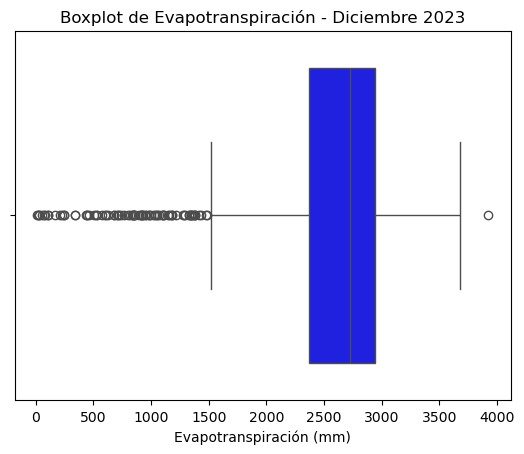

In [45]:
sns.boxplot(x=Datos_evap_gdf['Evap_mm'], color='blue')
plt.xlabel('Evapotranspiración (mm)')
plt.title('Boxplot de Evapotranspiración - Diciembre 2023')

Text(0.5, 0, 'Coordenada X')

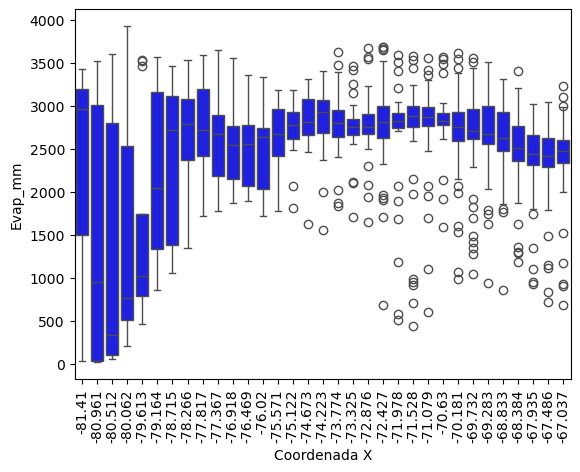

In [49]:
sns.boxplot(x=np.round(Datos_evap_gdf['x'],3),y=Datos_evap_gdf['Evap_mm'], color='blue')
plt.xticks(rotation=90)
plt.xlabel('Coordenada X')

Text(0.5, 0, 'Coordenada Y')

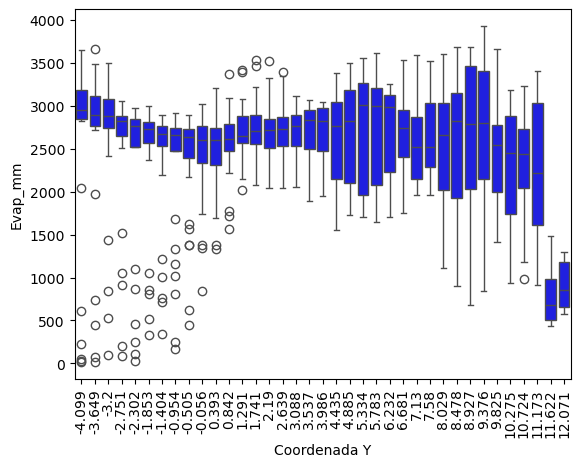

In [50]:
sns.boxplot(x=np.round(Datos_evap_gdf['y'],3),y=Datos_evap_gdf['Evap_mm'], color='blue')
plt.xticks(rotation=90)
plt.xlabel('Coordenada Y')

Text(0.5, 0, 'Evapotranspiración (mm)')

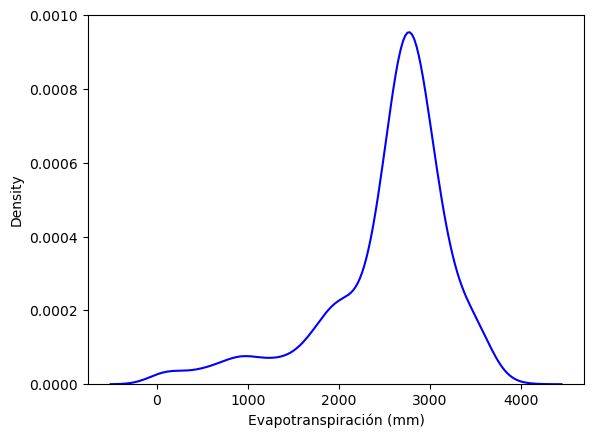

In [51]:
sns.kdeplot(x=Datos_evap_gdf['Evap_mm'], color='blue')
plt.xlabel('Evapotranspiración (mm)')

<Axes: xlabel='x', ylabel='y'>

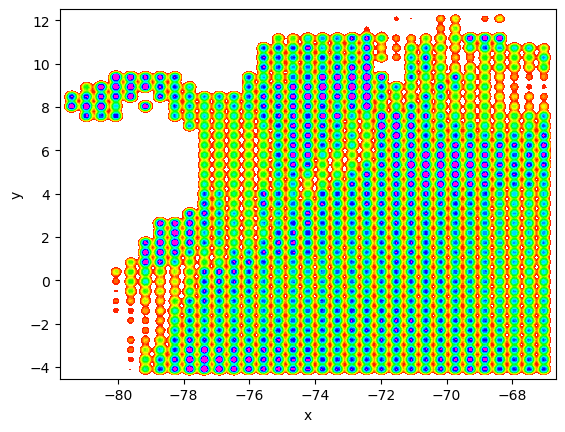

In [75]:
sns.kdeplot(data=Datos_evap_gdf, x='x', y='y',fill=True, 
            cmap='hsv', bw_adjust=0.1, weights='Evap_mm',levels=20)


# EJERCICIO:

### INTENTALO CON LOS DATOS DE PRECIPITACIÓN

In [ ]:
Datos_clima = pd.read_excel('CilmaCol.xlsx')


In [ ]:
Datos_clima['Fecha'] = pd.to_datetime(Datos_clima['Fecha'], format='%Y-%m-%d')
Datos_clima

,Fecha,Año,Mes,X,Y,TempAire,VelViento,Presion,Precipitacion,HumedadEsp,HumedadSuelo,Evapotranspiracion,NAME_1,NAME_2
0,1983-01-01,1983,1,-71.977587,12.071149,298.885620,11.425956,100266.101562,0.894141,0.015530,0.172283,8.753332,La Guajira,Uribía
1,1983-01-01,1983,1,-71.528429,12.071149,298.151855,11.874176,99533.500000,3.158118,0.015490,0.183878,12.346444,La Guajira,Uribía
2,1983-01-01,1983,1,-72.426745,11.621991,299.933716,8.104766,100808.109375,0.132512,0.015349,0.165928,8.986830,La Guajira,Manaure
3,1983-01-01,1983,1,-74.223375,11.172834,297.953369,5.378180,93993.281250,7.888172,0.013843,0.212550,63.672807,Magdalena,Santa Marta
4,1983-01-01,1983,1,-73.774218,11.172834,289.128113,4.781428,80832.828125,33.110129,0.010125,0.325880,89.027335,Magdalena,Santa Marta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226315,2023-12-01,2023,12,-70.180957,-2.301895,299.599731,1.394838,99439.281250,351.716774,0.019510,0.429802,118.648327,Amazonas,Tarapacá
226316,2023-12-01,2023,12,-69.731799,-2.301895,299.621948,1.392996,99416.109375,340.657488,0.019544,0.428736,117.632519,Amazonas,Tarapacá
226317,2023-12-01,2023,12,-69.731799,-2.751053,299.770355,1.389354,99633.921875,339.380410,0.019622,0.426158,120.141209,Amazonas,Tarapacá
226318,2023-12-01,2023,12,-70.180957,-3.200211,299.639496,1.407515,99461.742188,323.495597,0.019490,0.424875,121.801014,Amazonas,Leticia


In [80]:
Datos_clima.set_index('Fecha', inplace=True)
Datos_clima

,Año,Mes,X,Y,TempAire,VelViento,Presion,Precipitacion,HumedadEsp,HumedadSuelo,Evapotranspiracion,NAME_1,NAME_2
Fecha,,,,,,,,,,,,,
1983-01-01,1983,1,-71.977587,12.071149,298.885620,11.425956,100266.101562,0.894141,0.015530,0.172283,8.753332,La Guajira,Uribía
1983-01-01,1983,1,-71.528429,12.071149,298.151855,11.874176,99533.500000,3.158118,0.015490,0.183878,12.346444,La Guajira,Uribía
1983-01-01,1983,1,-72.426745,11.621991,299.933716,8.104766,100808.109375,0.132512,0.015349,0.165928,8.986830,La Guajira,Manaure
1983-01-01,1983,1,-74.223375,11.172834,297.953369,5.378180,93993.281250,7.888172,0.013843,0.212550,63.672807,Magdalena,Santa Marta
1983-01-01,1983,1,-73.774218,11.172834,289.128113,4.781428,80832.828125,33.110129,0.010125,0.325880,89.027335,Magdalena,Santa Marta
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-01,2023,12,-70.180957,-2.301895,299.599731,1.394838,99439.281250,351.716774,0.019510,0.429802,118.648327,Amazonas,Tarapacá
2023-12-01,2023,12,-69.731799,-2.301895,299.621948,1.392996,99416.109375,340.657488,0.019544,0.428736,117.632519,Amazonas,Tarapacá
2023-12-01,2023,12,-69.731799,-2.751053,299.770355,1.389354,99633.921875,339.380410,0.019622,0.426158,120.141209,Amazonas,Tarapacá


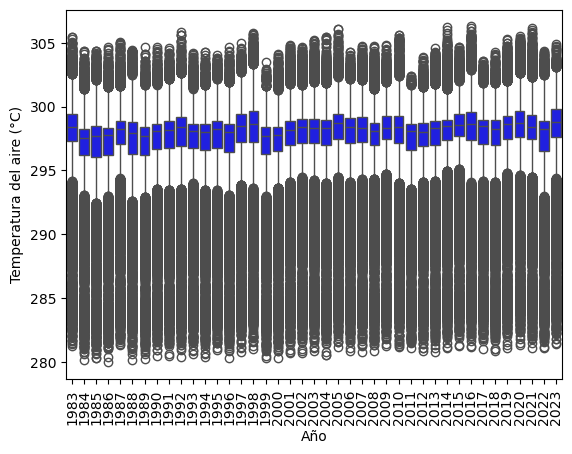

In [82]:
sns.boxplot(x=Datos_clima["Año"], y=Datos_clima["TempAire"], color='blue')
plt.xlabel('Año')
plt.ylabel('Temperatura del aire (°C)')
plt.xticks(rotation=90)
plt.show()

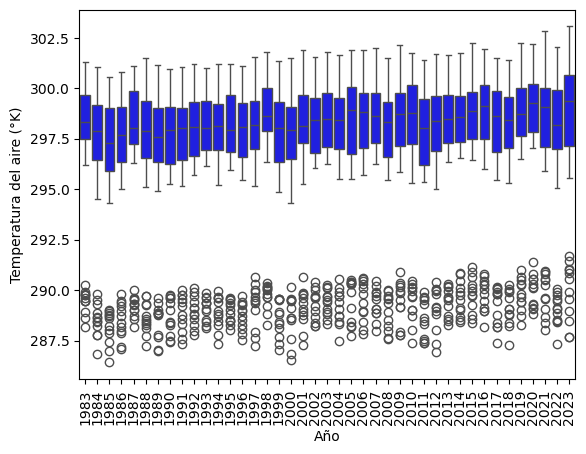

In [105]:
GJR = Datos_clima[Datos_clima["NAME_1"]=="La Guajira"]
sns.boxplot(x=GJR["Año"], y=GJR["TempAire"], color='blue')
plt.xlabel('Año')
plt.ylabel('Temperatura del aire (°K)')
plt.xticks(rotation=90)
plt.show()

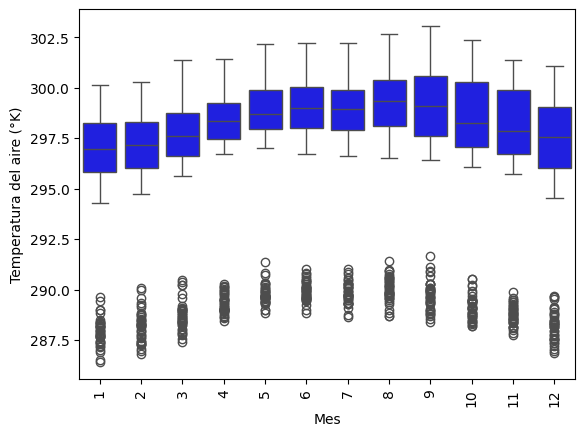

In [104]:
sns.boxplot(x=GJR["Mes"], y=GJR["TempAire"], color='blue')
plt.xlabel('Mes')
plt.ylabel('Temperatura del aire (°K)')
plt.xticks(rotation=90)
plt.show()

Text(0.5, 0, 'Temperatura del aire (°K)')

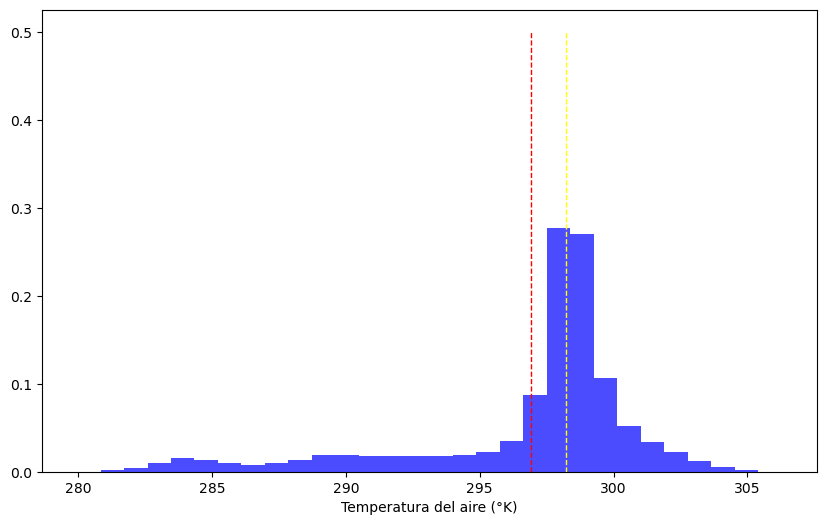

In [87]:
plt.figure(figsize=(10, 6))
plt.hist(Datos_clima['TempAire'], bins=30, color='blue', alpha=0.7, density=True)
plt.vlines(Datos_clima['TempAire'].mean(), 0, 0.5, color='red', linestyle='dashed', linewidth=1)
plt.vlines(Datos_clima['TempAire'].median(), 0, 0.5, color='yellow', linestyle='dashed', linewidth=1)
plt.xlabel('Temperatura del aire (°K)')

In [121]:
print(Datos_clima.groupby([Datos_clima.index.year, Datos_clima.index.month]).first())

              Año  Mes          X          Y    TempAire  VelViento  \
Fecha Fecha                                                           
1983  1      1983    1 -71.977587  12.071149  298.885620  11.425956   
      2      1983    2 -71.977587  12.071149  298.845764  10.346611   
      3      1983    3 -71.977587  12.071149  299.637421   9.432939   
      4      1983    4 -71.977587  12.071149  299.625122   9.579493   
      5      1983    5 -71.977587  12.071149  300.155090   9.977524   
...           ...  ...        ...        ...         ...        ...   
2023  8      2023    8 -71.977587  12.071149  301.776154   8.839477   
      9      2023    9 -71.977587  12.071149  302.321442   9.084073   
      10     2023   10 -71.977587  12.071149  302.157471   5.963953   
      11     2023   11 -71.977587  12.071149  301.272339   8.195345   
      12     2023   12 -71.977587  12.071149  300.418884   9.653481   

                   Presion  Precipitacion  HumedadEsp  HumedadSuelo  \
Fecha

In [ ]:
print(Datos_clima.groupby(pd.Grouper(freq='YE')).max())

             Año  Mes          X          Y    TempAire  VelViento  \
Fecha                                                                
1983-12-31  1983   12 -67.036853  12.071149  305.427856  11.874176   
1984-12-31  1984   12 -67.036853  12.071149  304.390869  11.778873   
1985-12-31  1985   12 -67.036853  12.071149  304.359192  12.480457   
1986-12-31  1986   12 -67.036853  12.071149  304.662292  12.399950   
1987-12-31  1987   12 -67.036853  12.071149  305.031494  11.944506   
1988-12-31  1988   12 -67.036853  12.071149  304.410889  11.334738   
1989-12-31  1989   12 -67.036853  12.071149  304.700745  11.734572   
1990-12-31  1990   12 -67.036853  12.071149  304.644653  11.846377   
1991-12-31  1991   12 -67.036853  12.071149  304.566650  11.849014   
1992-12-31  1992   12 -67.036853  12.071149  305.831116  12.719436   
1993-12-31  1993   12 -67.036853  12.071149  304.238373  12.072384   
1994-12-31  1994   12 -67.036853  12.071149  304.296661  13.023849   
1995-12-31  1995   1

C:\Users\valiz\AppData\Local\Temp\ipykernel_22288\2324786490.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  print(Datos_clima.groupby(pd.Grouper(freq='Y')).max())


In [145]:
print(Datos_clima.select_dtypes(include='number').groupby(pd.Grouper(freq='ME')).median())

               Año   Mes         X         Y    TempAire  VelViento  \
Fecha                                                                 
1983-01-31  1983.0   1.0 -73.32506  3.537154  299.470428   2.339821   
1983-02-28  1983.0   2.0 -73.32506  3.537154  299.480881   2.177356   
1983-03-31  1983.0   3.0 -73.32506  3.537154  299.471588   2.058784   
1983-04-30  1983.0   4.0 -73.32506  3.537154  298.536346   1.858391   
1983-05-31  1983.0   5.0 -73.32506  3.537154  298.290329   1.732636   
...            ...   ...       ...       ...         ...        ...   
2023-08-31  2023.0   8.0 -73.32506  3.537154  299.089752   1.772128   
2023-09-30  2023.0   9.0 -73.32506  3.537154  299.558990   1.697057   
2023-10-31  2023.0  10.0 -73.32506  3.537154  299.623199   1.726840   
2023-11-30  2023.0  11.0 -73.32506  3.537154  299.316727   1.817074   
2023-12-31  2023.0  12.0 -73.32506  3.537154  299.330765   1.934082   

                 Presion  Precipitacion  HumedadEsp  HumedadSuelo  \
Fecha  

In [146]:
print(Datos_clima.select_dtypes(include='number').groupby(pd.Grouper(freq='ME')).mean())

               Año   Mes          X         Y    TempAire  VelViento  \
Fecha                                                                  
1983-01-31  1983.0   1.0 -73.077047  3.859376  298.088937   2.699463   
1983-02-28  1983.0   2.0 -73.077047  3.859376  298.349728   2.548597   
1983-03-31  1983.0   3.0 -73.077047  3.859376  298.477603   2.416339   
1983-04-30  1983.0   4.0 -73.077047  3.859376  297.418362   2.168938   
1983-05-31  1983.0   5.0 -73.077047  3.859376  296.946980   2.063875   
...            ...   ...        ...       ...         ...        ...   
2023-08-31  2023.0   8.0 -73.077047  3.859376  297.865444   2.101752   
2023-09-30  2023.0   9.0 -73.077047  3.859376  298.334456   2.048507   
2023-10-31  2023.0  10.0 -73.077047  3.859376  298.086535   2.008037   
2023-11-30  2023.0  11.0 -73.077047  3.859376  297.736000   2.124612   
2023-12-31  2023.0  12.0 -73.077047  3.859376  298.022344   2.269218   

                 Presion  Precipitacion  HumedadEsp  HumedadSue

In [149]:
GJR_mean = GJR.select_dtypes(include='number').groupby(pd.Grouper(freq='ME')).mean()
GJR_max = GJR.select_dtypes(include='number').groupby(pd.Grouper(freq='ME')).max()
GJR_min = GJR.select_dtypes(include='number').groupby(pd.Grouper(freq='ME')).min()

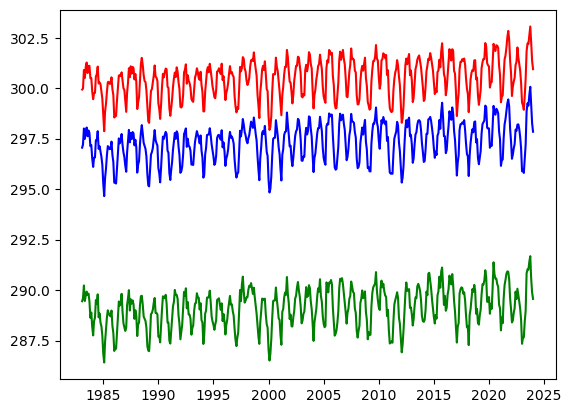

In [157]:
plt.plot(GJR_mean.index, GJR_mean['TempAire'], label='Media', color='blue')
plt.plot(GJR_max.index, GJR_max['TempAire'], label='Máximo', color='red')
plt.plot(GJR_min.index, GJR_min['TempAire'], label='Máximo', color='green')

In [94]:
import xarray as xr

# Seleccionar columnas a incluir (excluyendo 'Año' y 'Mes')
vars_to_include = [col for col in Datos_clima.columns if col not in ['Año', 'Mes']]

# Crear el xarray Dataset
ds = xr.Dataset.from_dataframe(
    Datos_clima[vars_to_include]
)

# Renombrar las dimensiones y coordenadas
ds = ds.rename({'X': 'lon', 'Y': 'lat', 'Fecha': 'time'})

# Asignar las coordenadas explícitamente
ds = ds.assign_coords(
    lon=('index', Datos_clima['X']),
    lat=('index', Datos_clima['Y']),
    time=('index', Datos_clima.index)
)

ds

<xarray.Dataset>
Dimensions:             (index: 226320, time: 226320)
Coordinates:
  * time                (index) datetime64[ns] 1983-01-01 ... 2023-12-01
    lon                 (index) float64 -71.98 -71.53 -72.43 ... -70.18 -70.18
    lat                 (index) float64 12.07 12.07 11.62 ... -2.751 -3.2 -3.649
Dimensions without coordinates: index
Data variables:
    TempAire            (time) float64 298.9 298.2 299.9 ... 299.8 299.6 299.8
    VelViento           (time) float64 11.43 11.87 8.105 ... 1.389 1.408 1.414
    Presion             (time) float64 1.003e+05 9.953e+04 ... 9.961e+04
    Precipitacion       (time) float64 0.8941 3.158 0.1325 ... 339.4 323.5 321.7
    HumedadEsp          (time) float64 0.01553 0.01549 ... 0.01949 0.01935
    HumedadSuelo        (time) float64 0.1723 0.1839 0.1659 ... 0.4249 0.4234
    Evapotranspiracion  (time) float64 8.753 12.35 8.987 ... 120.1 121.8 124.1
    NAME_1              (time) object 'La Guajira' 'La Guajira' ... 'Amazonas'
    NAME_2              (time) object 'Uribía' 'Uribía' ... 'Leticia' 'Leticia'

In [96]:
# Asignar atributos de unidades a las variables relevantes en el xarray Dataset
ds['TempAire'].attrs['units'] = 'K'
ds['Precipitacion'].attrs['units'] = 'kg/m^2/s'
ds['Evapotranspiracion'].attrs['units'] = 'kg/m^2/s'
ds['HumedadSuelo'].attrs['units'] = 'm^3/m^3'
ds['Presion'].attrs['units'] = 'Pa'
ds['HumedadEsp'].attrs['units'] = 'Masa Frac'
ds['VelViento'].attrs['units'] = 'm/s'

ds

<xarray.Dataset>
Dimensions:             (index: 226320, time: 226320)
Coordinates:
  * time                (index) datetime64[ns] 1983-01-01 ... 2023-12-01
    lon                 (index) float64 -71.98 -71.53 -72.43 ... -70.18 -70.18
    lat                 (index) float64 12.07 12.07 11.62 ... -2.751 -3.2 -3.649
Dimensions without coordinates: index
Data variables:
    TempAire            (time) float64 298.9 298.2 299.9 ... 299.8 299.6 299.8
    VelViento           (time) float64 11.43 11.87 8.105 ... 1.389 1.408 1.414
    Presion             (time) float64 1.003e+05 9.953e+04 ... 9.961e+04
    Precipitacion       (time) float64 0.8941 3.158 0.1325 ... 339.4 323.5 321.7
    HumedadEsp          (time) float64 0.01553 0.01549 ... 0.01949 0.01935
    HumedadSuelo        (time) float64 0.1723 0.1839 0.1659 ... 0.4249 0.4234
    Evapotranspiracion  (time) float64 8.753 12.35 8.987 ... 120.1 121.8 124.1
    NAME_1              (time) object 'La Guajira' 'La Guajira' ... 'Amazonas'
    NAME_2              (time) object 'Uribía' 'Uribía' ... 'Leticia' 'Leticia'

In [99]:
promedio_temp_aire = ds['TempAire'].mean().item()
print(f"Promedio de TempAire: {promedio_temp_aire:.2f} K")

Promedio de TempAire: 296.90 K


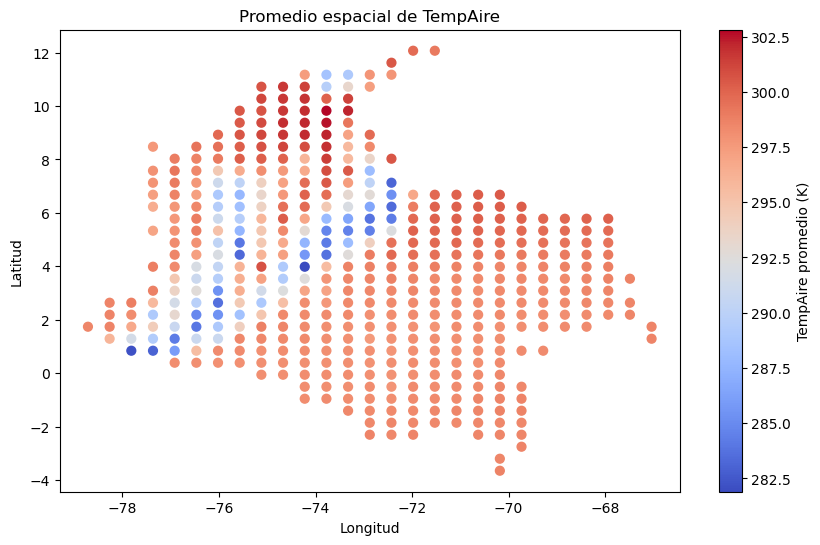

In [ ]:
# Calcular el promedio de TempAire por ubicación (lon, lat)
df_temp_prom = Datos_clima.groupby(['X', 'Y'])['TempAire'].mean().reset_index()

# Graficar
plt.figure(figsize=(10, 6))
sc = plt.scatter(df_temp_prom['X'], df_temp_prom['Y'], c=df_temp_prom['TempAire'], cmap='coolwarm', s=40)
plt.colorbar(sc, label='TempAire promedio (K)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Promedio espacial de TempAire')
plt.show()

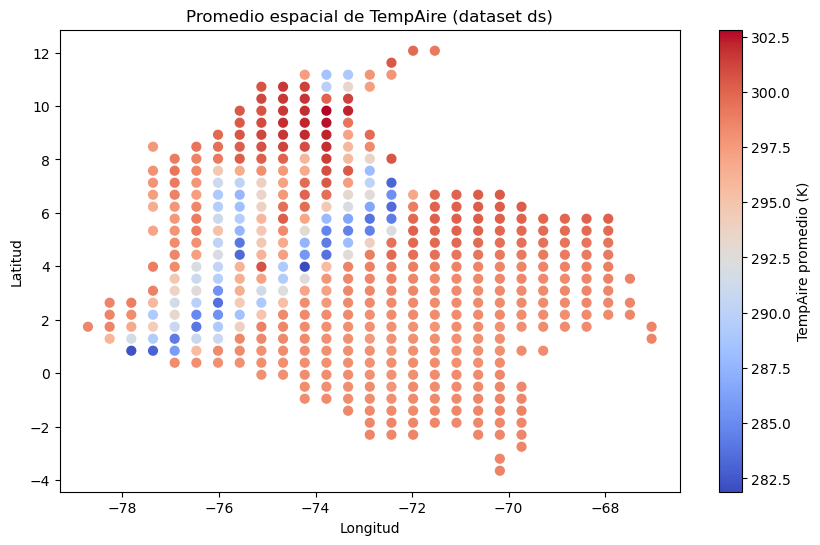

In [102]:
df_temp_prom_ds = pd.DataFrame({
    'lon': ds['lon'].values,
    'lat': ds['lat'].values,
    'TempAire': ds['TempAire'].values
}).groupby(['lon', 'lat'])['TempAire'].mean().reset_index()

plt.figure(figsize=(10, 6))
sc = plt.scatter(df_temp_prom_ds['lon'], df_temp_prom_ds['lat'], c=df_temp_prom_ds['TempAire'], cmap='coolwarm', s=40)
plt.colorbar(sc, label='TempAire promedio (K)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Promedio espacial de TempAire (dataset ds)')
plt.show()